In [1]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Details:", tf.config.list_physical_devices('GPU'))
print("Is Built with CUDA:", tf.test.is_built_with_cuda())


2025-06-29 02:25:23.513671: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-29 02:25:23.845068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751135123.961585     893 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751135123.992195     893 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751135124.249052     893 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Num GPUs Available: 1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Is Built with CUDA: True


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0, EfficientNetV2B1, EfficientNetV2B2, EfficientNetV2B3
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.applications import EfficientNetB7, EfficientNetB5
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Preprocessing

In [3]:
import os
import shutil
import random
from PIL import Image
from sklearn.model_selection import train_test_split

def resize_and_split_images(input_dir, output_dir, image_size=(224, 224), seed=42):
    random.seed(seed)

    # Supported image extensions
    valid_exts = ('.jpg', '.jpeg', '.png')

    # Collect all images from train, val, and test folders for each label
    combined_images = {}

    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(input_dir, split)
        if not os.path.exists(split_dir):
            print(f"Warning: {split_dir} does not exist.")
            continue

        for label in os.listdir(split_dir):
            label_path = os.path.join(split_dir, label)
            if not os.path.isdir(label_path):
                continue

            if label not in combined_images:
                combined_images[label] = []

            for fname in os.listdir(label_path):
                if fname.lower().endswith(valid_exts):
                    full_path = os.path.join(label_path, fname)
                    combined_images[label].append(full_path)

    # Check if we have exactly two classes (for binary classification)
    if len(combined_images) != 2:
        raise ValueError(f"Expected 2 classes for binary classification, but found {len(combined_images)}: {list(combined_images.keys())}")

    # Clear and recreate output directories
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(output_dir, split)
        if os.path.exists(split_dir):
            shutil.rmtree(split_dir)
        os.makedirs(split_dir)

    # Process each label
    for label, image_paths in combined_images.items():
        # Create label subfolders in train/val/test
        for split in ['train', 'val', 'test']:
            os.makedirs(os.path.join(output_dir, split, label), exist_ok=True)

        resized_images = []
        for path in image_paths:
            try:
                img = Image.open(path).convert('RGB')
                img = img.resize(image_size)
                resized_images.append((img, os.path.basename(path)))
            except Exception as e:
                print(f"Failed to process image {path}: {e}")

        if len(resized_images) == 0:
            print(f"Skipped {label}: no valid images found.")
            continue
        elif len(resized_images) < 3:
            print(f"Skipped {label}: only {len(resized_images)} image(s). Need at least 3 to split.")
            continue

        # Split
        test_ratio = 0.15
        val_ratio = 0.15
        train_val, test = train_test_split(resized_images, test_size=test_ratio, random_state=seed)
        val_relative_ratio = val_ratio / (1 - test_ratio)
        train, val = train_test_split(train_val, test_size=val_relative_ratio, random_state=seed)

        # Save
        for img, fname in train:
            img.save(os.path.join(output_dir, 'train', label, fname))
        for img, fname in val:
            img.save(os.path.join(output_dir, 'val', label, fname))
        for img, fname in test:
            img.save(os.path.join(output_dir, 'test', label, fname))

        print(f"Processed {label}: {len(train)} train, {len(val)} val, {len(test)} test")

# Example usage
resize_and_split_images(
    input_dir="/mnt/c/Users/YapJack/Desktop/DeepEarthMY",
    output_dir="/mnt/c/Users/YapJack/Desktop/DeepEarthMY (random split)",
    image_size=(224, 224)
)

Processed Rural: 1867 train, 401 val, 401 test
Processed Urban: 1375 train, 295 val, 295 test


In [4]:

# Set image size
IMG_SIZE = (224, 224)  # ResNet50 default input size
BATCH_SIZE = 16

# Load datasets from folders
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/mnt/c/Users/YapJack/Desktop/DeepEarthMY (random split)/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/mnt/c/Users/YapJack/Desktop/DeepEarthMY (random split)/val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/mnt/c/Users/YapJack/Desktop/DeepEarthMY (random split)/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)


Found 3242 files belonging to 2 classes.


I0000 00:00:1751135234.820810     893 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 696 files belonging to 2 classes.
Found 696 files belonging to 2 classes.


2025-06-29 02:27:20.326407: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-29 02:27:20.859092: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


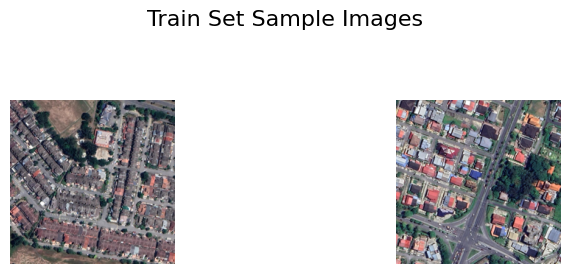

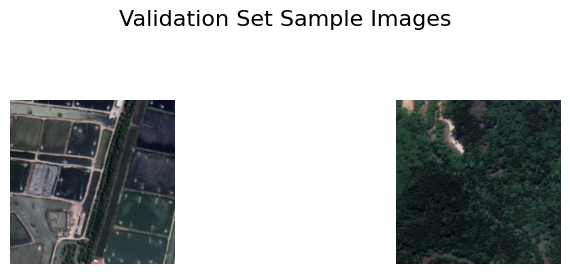

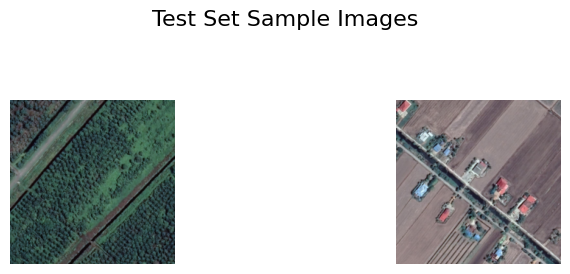

In [5]:
# Get class names from one of the datasets
class_names = train_dataset.class_names

def collect_images(dataset, class_names, num_images=2):
    """Collect a few sample images per class."""
    class_images = {class_name: [] for class_name in class_names}

    for images, labels in dataset:
        for img, lbl in zip(images, labels):
            class_index = tf.argmax(lbl).numpy()  # because of 'categorical' label_mode
            class_name = class_names[class_index]
            if len(class_images[class_name]) < num_images:
                class_images[class_name].append(img.numpy().astype("uint8"))
        if all(len(imgs) == num_images for imgs in class_images.values()):
            break
    return class_images

def visualize_dataset(class_images, title="Sample Images"):
    """Visualize the collected images."""
    num_classes = len(class_images)
    plt.figure(figsize=(8, num_classes * 2.5))
    for i, (class_name, imgs) in enumerate(class_images.items()):
        for j, img in enumerate(imgs):
            ax = plt.subplot(num_classes, 2, i * 2 + j + 1)
            plt.imshow(img)
            if j == 0:
                ax.set_ylabel(class_name, fontsize=12)
            plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(pad=2.0, rect=[0, 0.03, 1, 0.95])
    plt.show()

# Collect and visualize
train_images = collect_images(train_dataset, class_names, num_images=2)
val_images = collect_images(val_dataset, class_names, num_images=2)
test_images = collect_images(test_dataset, class_names, num_images=2)

visualize_dataset(train_images, title="Train Set Sample Images")
visualize_dataset(val_images, title="Validation Set Sample Images")
visualize_dataset(test_images, title="Test Set Sample Images")

# Model Construction

In [19]:
# Build the EfficientNetV2B3 model from scratch (no pretrained weights)
base_model2 = EfficientNetV2B2(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model2 = keras.Sequential([
    base_model2, # <== EfficientNetV2B3
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b2 (Functional)  │ (None, 1408)           │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,625,439 (36.72 MB)

 Trainable params: 9,541,615 (36.40 MB)

 Non-trainable params: 83,824 (327.44 KB)

In [20]:
early_stopping_efficient = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient2 = keras.callbacks.ModelCheckpoint(
    'efficientNetV2-B2_decay_DEMV2_random.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [21]:
history_efficient2 = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient2, early_stopping_efficient]  # include your early stopping too
)

Epoch 1/100


I0000 00:00:1751000526.698371    1600 service.cc:152] XLA service 0x7f250c03b680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751000526.698399    1600 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-27 13:02:07.567558: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751000531.246032    1600 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-27 13:02:14.208562: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 4 bytes spill stores, 4 bytes spill loads

2025-06-27 13:02:14.472356: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015'

202/203 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7103 - loss: 0.7175

2025-06-27 13:02:52.975870: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 12 bytes spill stores, 12 bytes spill loads

2025-06-27 13:02:53.028546: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 40 bytes spill stores, 40 bytes spill loads

2025-06-27 13:02:53.158993: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 264 bytes spill stores, 264 bytes spill loads

2025-06-27 13:02:53.170133: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 40 bytes spill stores, 40 bytes spill loads

2025-06-27 13:02:53.518297: I exte

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7105 - loss: 0.7170

2025-06-27 13:03:19.385890: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 12 bytes spill stores, 12 bytes spill loads

2025-06-27 13:03:19.471120: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 264 bytes spill stores, 264 bytes spill loads

2025-06-27 13:03:19.487442: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-27 13:03:19.511488: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-27 13:03:19.858726: I external

203/203 ━━━━━━━━━━━━━━━━━━━━ 95s 226ms/step - accuracy: 0.7106 - loss: 0.7165 - val_accuracy: 0.8132 - val_loss: 0.5113
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.7719 - loss: 0.5280 - val_accuracy: 0.8649 - val_loss: 0.3428
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8350 - loss: 0.4075 - val_accuracy: 0.8621 - val_loss: 0.3419
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8500 - loss: 0.3507 - val_accuracy: 0.8621 - val_loss: 0.3024
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8784 - loss: 0.3152 - val_accuracy: 0.9023 - val_loss: 0.2267
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.8914 - loss: 0.2827 - val_accuracy: 0.8951 - val_loss: 0.2585
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9090 - loss: 0.2321 - val_accuracy: 0.9195 - val_loss: 0.2083
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9107 - loss: 0.2363 - val

In [6]:
best_model2 = keras.models.load_model('efficientNetV2-B2_decay_DEMV2_random.keras')

In [7]:
test_loss, test_acc = best_model2.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

I0000 00:00:1751135252.916271    1317 service.cc:152] XLA service 0x72afe80028e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751135252.916307    1317 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-29 02:27:33.030581: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751135253.574617    1317 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-29 02:27:33.906397: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 4 bytes spill stores, 4 bytes spill loads

2025-06-29 02:27:34.185785: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 

10/44 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9747 - loss: 0.2115

I0000 00:00:1751135259.235852    1317 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9585 - loss: 0.2432

2025-06-29 02:27:40.763247: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 12 bytes spill stores, 12 bytes spill loads

2025-06-29 02:27:40.992939: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-29 02:27:41.023610: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 264 bytes spill stores, 264 bytes spill loads

2025-06-29 02:27:41.146929: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-29 02:27:41.361490: I external

44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9582 - loss: 0.2435
Test accuracy: 0.9526, Test loss: 0.2499


In [25]:
# Reload test dataset with guaranteed ordering
test_dataset2 = tf.keras.preprocessing.image_dataset_from_directory(
    '/mnt/c/Users/YapJack/Desktop/DeepEarthMY (random split)/test',
    image_size=(224, 224),
    batch_size=16,
    label_mode='binary',
    shuffle=False
)

Found 696 files belonging to 2 classes.


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

def evaluate_model_binary(model, test_dataset2):
    """
    Evaluates a binary classification model on a given test dataset.

    Parameters:
    - model: Trained Keras model
    - test_dataset: A tf.data.Dataset (batched) with binary labels and shuffle=False

    Returns:
    - Dictionary with accuracy, precision, recall, and F1-score
    """
    # Extract true labels
    y_true = np.concatenate([y.numpy() for _, y in test_dataset2], axis=0).astype("int32").flatten()

    # Predict probabilities and threshold
    y_pred_probs = model.predict(test_dataset2)
    y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

    # Verify distributions
    print("True label distribution:", np.bincount(y_true))
    print("Predicted label distribution:", np.bincount(y_pred))

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print results
    print(f"Manual Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


evaluate_model_binary(best_model2, test_dataset2)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
True label distribution: [401 295]
Predicted label distribution: [398 298]
Manual Accuracy: 0.9526
Precision: 0.9396
Recall: 0.9492
F1-score: 0.9444


{'accuracy': 0.9525862068965517,
 'precision': 0.9395973154362416,
 'recall': 0.9491525423728814,
 'f1_score': 0.9443507588532883}

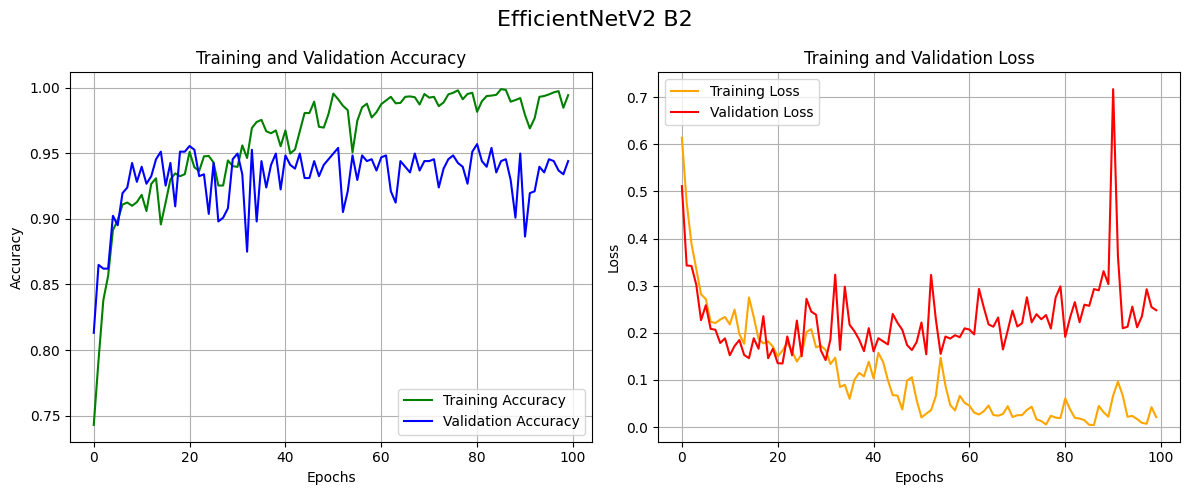

In [27]:
# Extract required metrics
train_acc = history_efficient2.history['accuracy']
train_loss = history_efficient2.history['loss']
val_acc = history_efficient2.history['val_accuracy']
val_loss = history_efficient2.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B2', fontsize=16)
plt.tight_layout()
plt.show()
